# Tutorial 16 — Generative Adversarial Network (GANs)

## Objective

This notebook implements **Tutorial 16: Generative Adversarial Networks (GANs)** using PyTorch.

The tutorial covers:

- Loading and preparing the MNIST dataset
- Building a fully connected Generator
- Building a fully connected Discriminator
- Training a basic GAN
- Generating new images from random noise
- Changing epochs and layers
- Replacing fully connected layers with convolutional layers
- Training a GAN on augmented images

The main tasks are:

1. Change the number of epochs and layers
2. Replace fully connected layers with convolutional layers for image generation
3. Develop the model for augmented images from a previous study


## 1. Import Required Libraries

In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

os.makedirs("images", exist_ok=True)


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Load and Prepare MNIST Dataset

The MNIST dataset contains grayscale handwritten digit images.

Each image has size:

```text
28 x 28
```

For GAN training, the pixel values are normalized to the range:

```text
[-1, 1]
```

This matches the `Tanh` activation used at the output of the generator.


In [2]:
batch_size = 64
USE_SUBSET = True
SUBSET_SIZE = 20000

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_full_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=mnist_transform
)

if USE_SUBSET:
    indices = np.arange(SUBSET_SIZE)
    mnist_dataset = Subset(mnist_full_dataset, indices)
else:
    mnist_dataset = mnist_full_dataset

mnist_loader = DataLoader(
    mnist_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

print("MNIST samples used:", len(mnist_dataset))


Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

MNIST samples used: 20000


## 3. Visualize Real MNIST Images

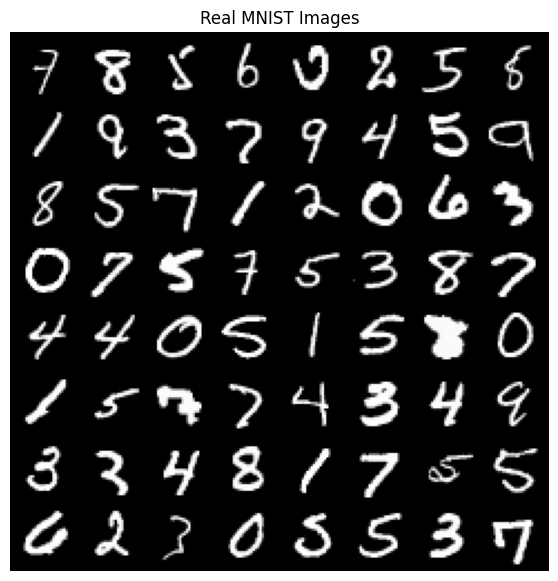

In [3]:
def show_image_grid(images, title, filename, nrow=8):
    images = images.detach().cpu()

    # Convert from [-1, 1] to [0, 1] for display
    images = (images + 1) / 2
    images = torch.clamp(images, 0, 1)

    grid = make_grid(images, nrow=nrow)

    plt.figure(figsize=(7, 7))
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


real_images, _ = next(iter(mnist_loader))

show_image_grid(
    real_images[:64],
    title="Real MNIST Images",
    filename="images/tutorial_16_real_mnist_samples.png",
    nrow=8
)


# Part A — Basic Fully Connected GAN

A GAN has two neural networks:

## Generator

The generator takes random noise as input and tries to generate fake images.

## Discriminator

The discriminator receives real or fake images and predicts whether the image is real or fake.

Both models are trained together in an adversarial process.


## 4. Define Basic Generator and Discriminator

In [4]:
latent_dim = 100
image_dim = 28 * 28

class FCGenerator(nn.Module):
    def __init__(self, latent_dim=100, image_dim=784):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, image_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(z.size(0), 1, 28, 28)
        return img


class FCDiscriminator(nn.Module):
    def __init__(self, image_dim=784):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(image_dim, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity


fc_generator = FCGenerator(latent_dim, image_dim).to(device)
fc_discriminator = FCDiscriminator(image_dim).to(device)

print(fc_generator)
print(fc_discriminator)


FCGenerator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=784, bias=True)
    (7): Tanh()
  )
)
FCDiscriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## 5. GAN Training Function

In [5]:
def train_gan(
    generator,
    discriminator,
    data_loader,
    epochs=10,
    latent_dim=100,
    learning_rate=0.0002,
    sample_filename_prefix="gan",
    visualize_every=5
):
    criterion = nn.BCELoss()

    generator_optimizer = torch.optim.Adam(generator.parameters(), lr=learning_rate)
    discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=learning_rate)

    history = {
        "generator_loss": [],
        "discriminator_loss": []
    }

    fixed_noise = torch.randn(64, latent_dim).to(device)

    start_time = time.time()

    for epoch in range(epochs):
        generator.train()
        discriminator.train()

        total_g_loss = 0.0
        total_d_loss = 0.0
        batches = 0

        for real_images, _ in data_loader:
            real_images = real_images.to(device)
            current_batch_size = real_images.size(0)

            real_labels = torch.ones(current_batch_size, 1).to(device)
            fake_labels = torch.zeros(current_batch_size, 1).to(device)

            # ---------------------
            # Train Discriminator
            # ---------------------
            discriminator_optimizer.zero_grad()

            real_outputs = discriminator(real_images)
            real_loss = criterion(real_outputs, real_labels)

            noise = torch.randn(current_batch_size, latent_dim).to(device)
            fake_images = generator(noise)

            fake_outputs = discriminator(fake_images.detach())
            fake_loss = criterion(fake_outputs, fake_labels)

            d_loss = real_loss + fake_loss
            d_loss.backward()
            discriminator_optimizer.step()

            # ---------------------
            # Train Generator
            # ---------------------
            generator_optimizer.zero_grad()

            noise = torch.randn(current_batch_size, latent_dim).to(device)
            generated_images = generator(noise)

            outputs = discriminator(generated_images)
            g_loss = criterion(outputs, real_labels)

            g_loss.backward()
            generator_optimizer.step()

            total_g_loss += g_loss.item()
            total_d_loss += d_loss.item()
            batches += 1

        avg_g_loss = total_g_loss / batches
        avg_d_loss = total_d_loss / batches

        history["generator_loss"].append(avg_g_loss)
        history["discriminator_loss"].append(avg_d_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"D Loss: {avg_d_loss:.4f} | "
            f"G Loss: {avg_g_loss:.4f}"
        )

        if (epoch + 1) % visualize_every == 0 or epoch == epochs - 1:
            generator.eval()
            with torch.no_grad():
                sample_images = generator(fixed_noise)

            show_image_grid(
                sample_images,
                title=f"Generated Images - Epoch {epoch + 1}",
                filename=f"images/{sample_filename_prefix}_epoch_{epoch + 1}.png",
                nrow=8
            )

    total_time = time.time() - start_time

    return history, total_time


def plot_gan_losses(history, title, filename):
    epochs_range = range(1, len(history["generator_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["generator_loss"], label="Generator Loss")
    plt.plot(epochs_range, history["discriminator_loss"], label="Discriminator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 6. Train the Basic Fully Connected GAN

Epoch 1/10 | D Loss: 0.4375 | G Loss: 1.6482
Epoch 2/10 | D Loss: 0.0992 | G Loss: 5.9851
Epoch 3/10 | D Loss: 0.3860 | G Loss: 7.3396
Epoch 4/10 | D Loss: 0.4412 | G Loss: 5.0139
Epoch 5/10 | D Loss: 1.0028 | G Loss: 3.0092


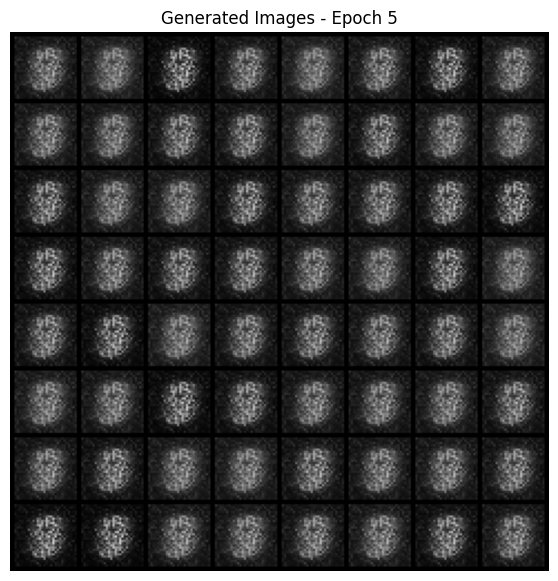

Epoch 6/10 | D Loss: 1.0913 | G Loss: 1.7201
Epoch 7/10 | D Loss: 1.0194 | G Loss: 2.1763
Epoch 8/10 | D Loss: 0.6344 | G Loss: 3.0990
Epoch 9/10 | D Loss: 0.3343 | G Loss: 2.9603
Epoch 10/10 | D Loss: 0.2352 | G Loss: 3.3228


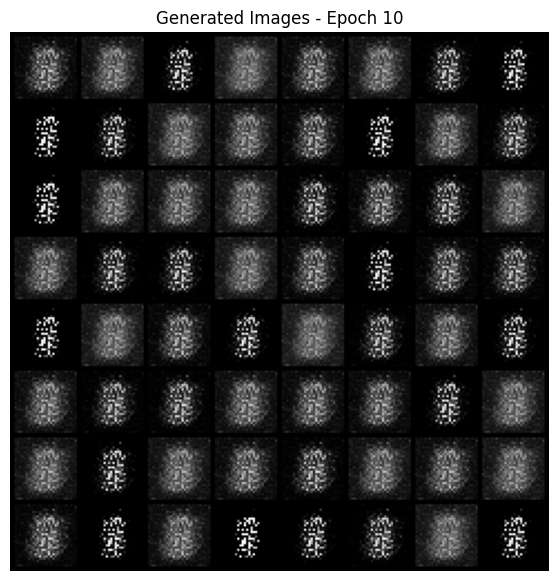

Fully connected GAN training time: 101.37 seconds
Generator parameters: 579728
Discriminator parameters: 533505


In [6]:
torch.manual_seed(SEED)

fc_generator = FCGenerator(latent_dim, image_dim).to(device)
fc_discriminator = FCDiscriminator(image_dim).to(device)

fc_history, fc_time = train_gan(
    fc_generator,
    fc_discriminator,
    mnist_loader,
    epochs=10,
    latent_dim=latent_dim,
    learning_rate=0.0002,
    sample_filename_prefix="tutorial_16_fc_gan",
    visualize_every=5
)

print("Fully connected GAN training time:", round(fc_time, 2), "seconds")
print("Generator parameters:", count_trainable_parameters(fc_generator))
print("Discriminator parameters:", count_trainable_parameters(fc_discriminator))


## 7. Plot Fully Connected GAN Losses

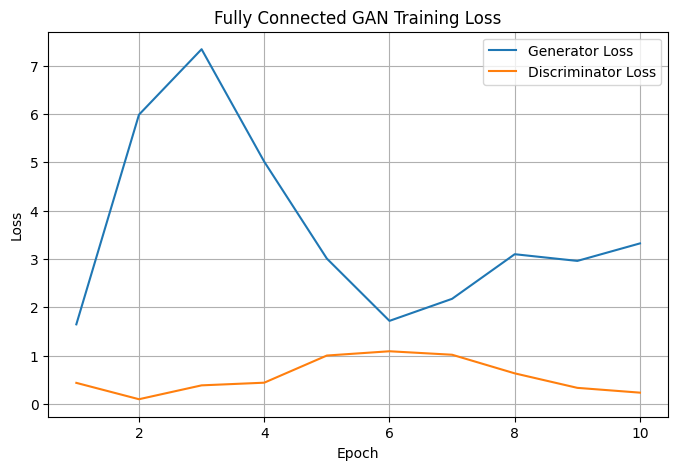

In [7]:
plot_gan_losses(
    fc_history,
    title="Fully Connected GAN Training Loss",
    filename="images/tutorial_16_fc_gan_loss.png"
)


## 8. Generate Final Images using Fully Connected GAN

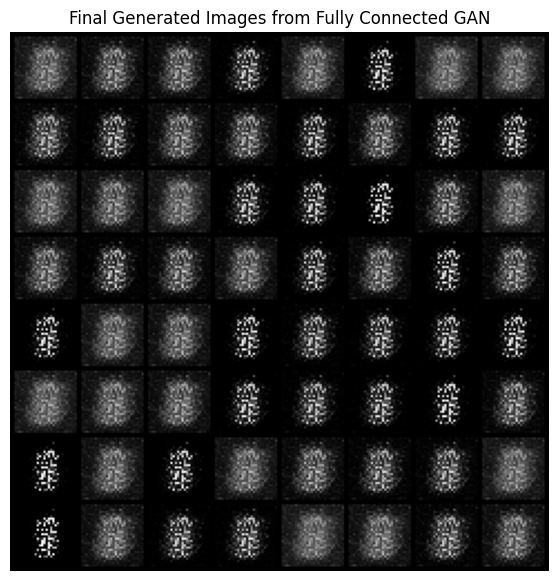

In [8]:
fc_generator.eval()

with torch.no_grad():
    noise = torch.randn(64, latent_dim).to(device)
    generated_fc_images = fc_generator(noise)

show_image_grid(
    generated_fc_images,
    title="Final Generated Images from Fully Connected GAN",
    filename="images/tutorial_16_fc_gan_final_generated.png",
    nrow=8
)


# Task 1 — Change Number of Epochs and Layers

The tutorial asks to change epochs and layers.

A deeper fully connected GAN is created and trained for comparison.


In [9]:
class DeepFCGenerator(nn.Module):
    def __init__(self, latent_dim=100, image_dim=784):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 512),
            nn.ReLU(),

            nn.Linear(512, image_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(z.size(0), 1, 28, 28)
        return img


class DeepFCDiscriminator(nn.Module):
    def __init__(self, image_dim=784):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(image_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity


torch.manual_seed(SEED)

deep_fc_generator = DeepFCGenerator(latent_dim, image_dim).to(device)
deep_fc_discriminator = DeepFCDiscriminator(image_dim).to(device)

print(deep_fc_generator)
print(deep_fc_discriminator)


DeepFCGenerator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=784, bias=True)
    (9): Tanh()
  )
)
DeepFCDiscriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Linear(in_features=256, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


Epoch 1/15 | D Loss: 0.6337 | G Loss: 2.6709
Epoch 2/15 | D Loss: 1.2297 | G Loss: 3.0305
Epoch 3/15 | D Loss: 1.2343 | G Loss: 1.9771
Epoch 4/15 | D Loss: 1.2460 | G Loss: 0.9731
Epoch 5/15 | D Loss: 1.3110 | G Loss: 1.0362


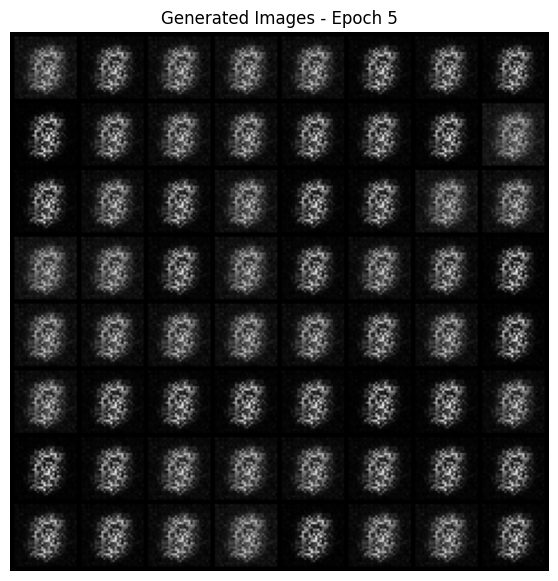

Epoch 6/15 | D Loss: 1.3557 | G Loss: 0.8017
Epoch 7/15 | D Loss: 1.1824 | G Loss: 1.2499
Epoch 8/15 | D Loss: 0.9717 | G Loss: 2.0817
Epoch 9/15 | D Loss: 0.6149 | G Loss: 2.8418
Epoch 10/15 | D Loss: 0.6245 | G Loss: 3.2665


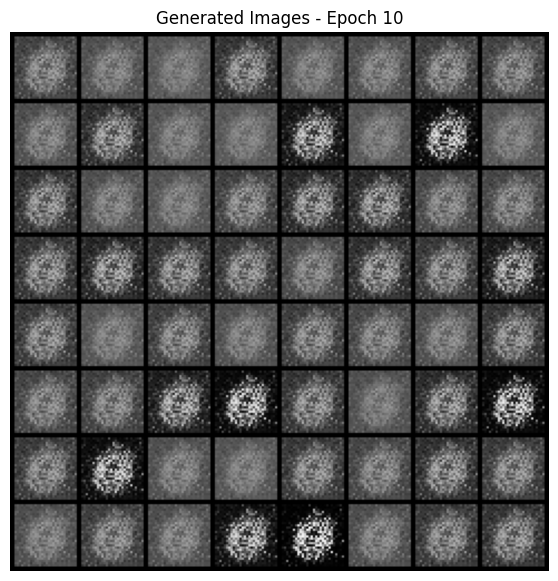

Epoch 11/15 | D Loss: 0.6316 | G Loss: 2.9186
Epoch 12/15 | D Loss: 0.6725 | G Loss: 3.2565
Epoch 13/15 | D Loss: 0.4876 | G Loss: 2.7268
Epoch 14/15 | D Loss: 0.5808 | G Loss: 3.1055
Epoch 15/15 | D Loss: 0.4979 | G Loss: 2.6569


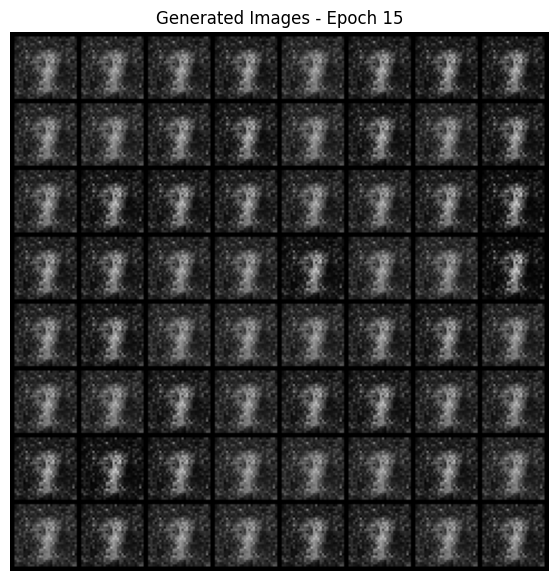

Deep fully connected GAN training time: 171.19 seconds
Generator parameters: 1609744
Discriminator parameters: 1460225


In [10]:
deep_fc_history, deep_fc_time = train_gan(
    deep_fc_generator,
    deep_fc_discriminator,
    mnist_loader,
    epochs=15,
    latent_dim=latent_dim,
    learning_rate=0.0002,
    sample_filename_prefix="tutorial_16_deep_fc_gan",
    visualize_every=5
)

print("Deep fully connected GAN training time:", round(deep_fc_time, 2), "seconds")
print("Generator parameters:", count_trainable_parameters(deep_fc_generator))
print("Discriminator parameters:", count_trainable_parameters(deep_fc_discriminator))


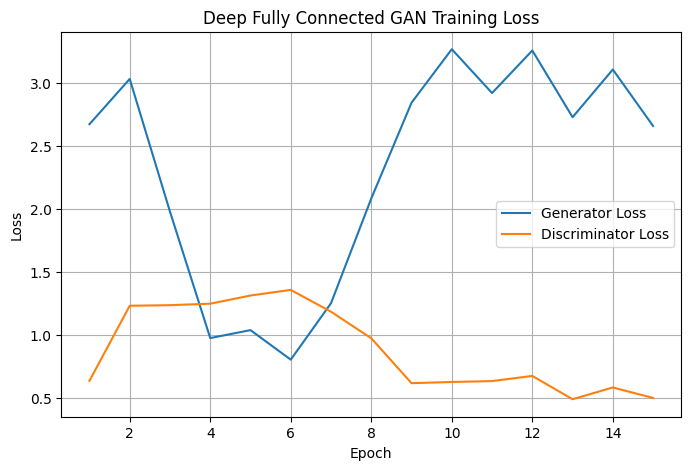

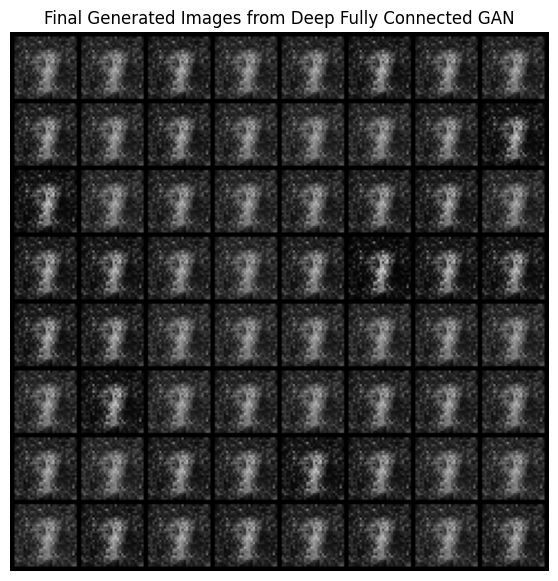

In [11]:
plot_gan_losses(
    deep_fc_history,
    title="Deep Fully Connected GAN Training Loss",
    filename="images/tutorial_16_deep_fc_gan_loss.png"
)

deep_fc_generator.eval()

with torch.no_grad():
    noise = torch.randn(64, latent_dim).to(device)
    generated_deep_fc_images = deep_fc_generator(noise)

show_image_grid(
    generated_deep_fc_images,
    title="Final Generated Images from Deep Fully Connected GAN",
    filename="images/tutorial_16_deep_fc_gan_final_generated.png",
    nrow=8
)


# Task 2 — Replace Fully Connected Layers with Convolutional Layers

A DCGAN-style model is created using:

- ConvTranspose2d layers in the generator
- Conv2d layers in the discriminator

This is more suitable for image generation because convolutional layers preserve spatial image structure.


In [12]:
class DCGANGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.project = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU()
        )

        self.conv_blocks = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 14 -> 28
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.project(z)
        x = x.view(z.size(0), 128, 7, 7)
        img = self.conv_blocks(x)
        return img


class DCGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28 -> 14
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 14 -> 7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        validity = self.model(img)
        return validity


torch.manual_seed(SEED)

dcgan_generator = DCGANGenerator(latent_dim).to(device)
dcgan_discriminator = DCGANDiscriminator().to(device)

print(dcgan_generator)
print(dcgan_discriminator)


DCGANGenerator(
  (project): Sequential(
    (0): Linear(in_features=100, out_features=6272, bias=True)
    (1): BatchNorm1d(6272, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (conv_blocks): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Tanh()
  )
)
DCGANDiscriminator(
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, 

Epoch 1/15 | D Loss: 0.3684 | G Loss: 2.7440
Epoch 2/15 | D Loss: 0.6760 | G Loss: 1.7917
Epoch 3/15 | D Loss: 0.7883 | G Loss: 1.4769
Epoch 4/15 | D Loss: 0.8058 | G Loss: 1.5404
Epoch 5/15 | D Loss: 0.6199 | G Loss: 1.6723


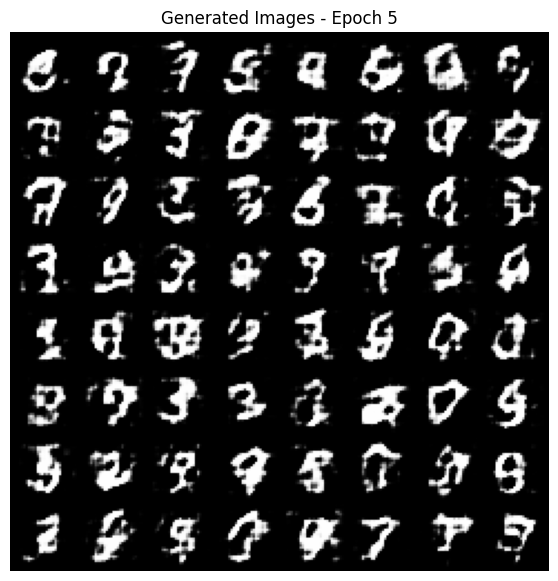

Epoch 6/15 | D Loss: 0.5535 | G Loss: 1.9335
Epoch 7/15 | D Loss: 0.4580 | G Loss: 2.0647
Epoch 8/15 | D Loss: 0.4471 | G Loss: 2.2041
Epoch 9/15 | D Loss: 0.4429 | G Loss: 2.2506
Epoch 10/15 | D Loss: 0.4826 | G Loss: 2.2856


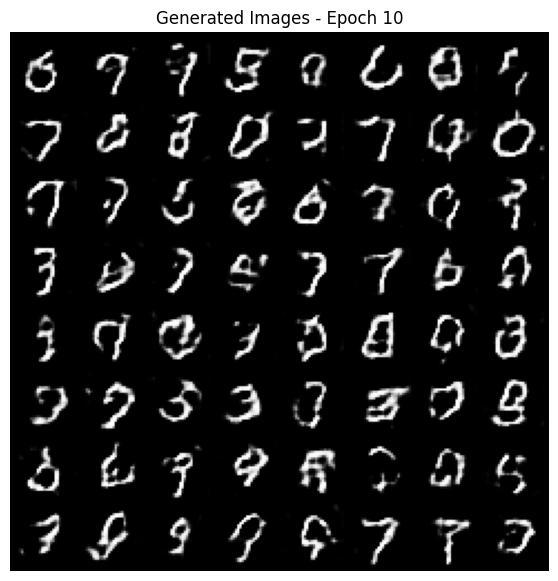

Epoch 11/15 | D Loss: 0.5281 | G Loss: 2.0300
Epoch 12/15 | D Loss: 0.5810 | G Loss: 1.9493
Epoch 13/15 | D Loss: 0.6239 | G Loss: 1.9120
Epoch 14/15 | D Loss: 0.6647 | G Loss: 1.8010
Epoch 15/15 | D Loss: 0.7013 | G Loss: 1.7648


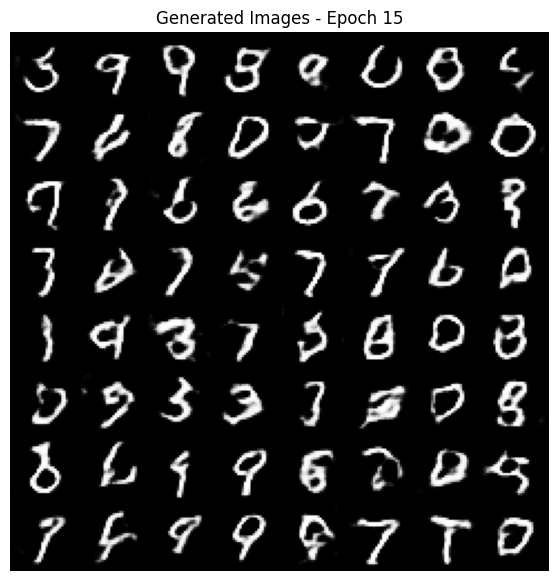

DCGAN training time: 178.63 seconds
Generator parameters: 810433
Discriminator parameters: 36641


In [13]:
dcgan_history, dcgan_time = train_gan(
    dcgan_generator,
    dcgan_discriminator,
    mnist_loader,
    epochs=15,
    latent_dim=latent_dim,
    learning_rate=0.0002,
    sample_filename_prefix="tutorial_16_dcgan",
    visualize_every=5
)

print("DCGAN training time:", round(dcgan_time, 2), "seconds")
print("Generator parameters:", count_trainable_parameters(dcgan_generator))
print("Discriminator parameters:", count_trainable_parameters(dcgan_discriminator))


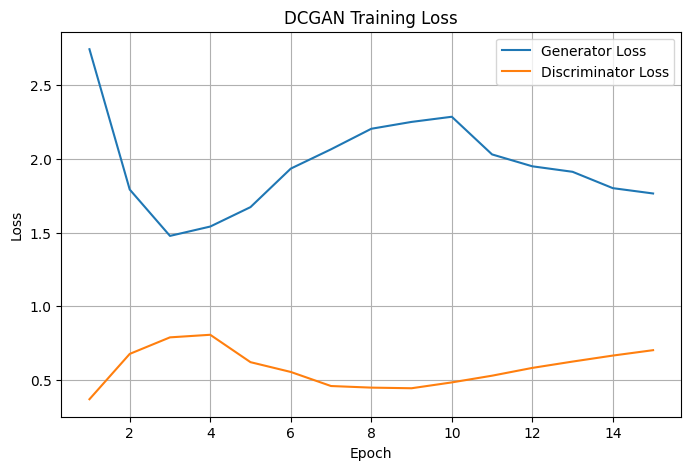

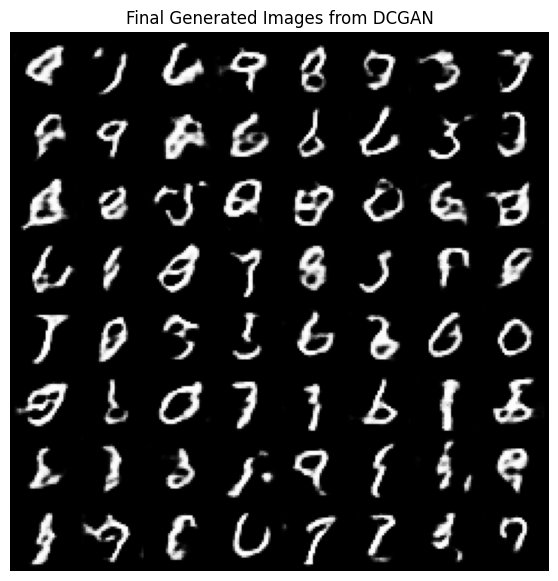

In [14]:
plot_gan_losses(
    dcgan_history,
    title="DCGAN Training Loss",
    filename="images/tutorial_16_dcgan_loss.png"
)

dcgan_generator.eval()

with torch.no_grad():
    noise = torch.randn(64, latent_dim).to(device)
    generated_dcgan_images = dcgan_generator(noise)

show_image_grid(
    generated_dcgan_images,
    title="Final Generated Images from DCGAN",
    filename="images/tutorial_16_dcgan_final_generated.png",
    nrow=8
)


# Task 3 — GAN for Augmented Images

The tutorial asks to develop the model for augmented images from a study conducted during the course.

Here, MNIST images are augmented using random affine transformations and the DCGAN model is trained on these augmented images.

This connects with the earlier data augmentation concept.


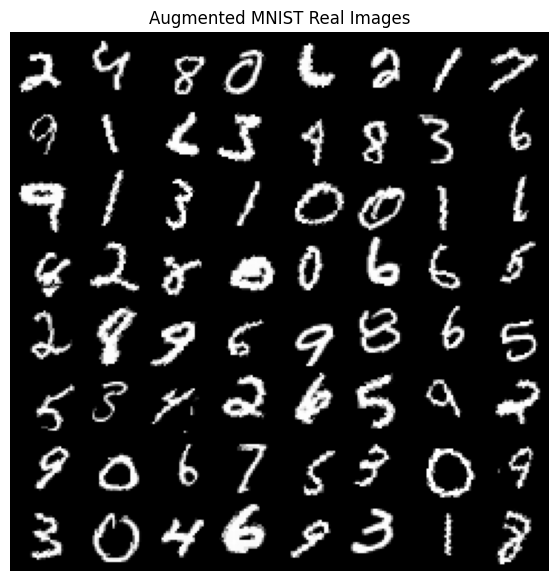

In [15]:
augmented_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=20,
        translate=(0.10, 0.10),
        scale=(0.90, 1.10)
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

augmented_mnist_full_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=augmented_transform
)

if USE_SUBSET:
    augmented_mnist_dataset = Subset(augmented_mnist_full_dataset, indices)
else:
    augmented_mnist_dataset = augmented_mnist_full_dataset

augmented_loader = DataLoader(
    augmented_mnist_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

augmented_real_images, _ = next(iter(augmented_loader))

show_image_grid(
    augmented_real_images[:64],
    title="Augmented MNIST Real Images",
    filename="images/tutorial_16_augmented_mnist_samples.png",
    nrow=8
)


Epoch 1/10 | D Loss: 0.4541 | G Loss: 2.5843
Epoch 2/10 | D Loss: 0.6287 | G Loss: 1.7209
Epoch 3/10 | D Loss: 0.7776 | G Loss: 1.6091
Epoch 4/10 | D Loss: 0.7190 | G Loss: 1.5888
Epoch 5/10 | D Loss: 0.6534 | G Loss: 1.6765


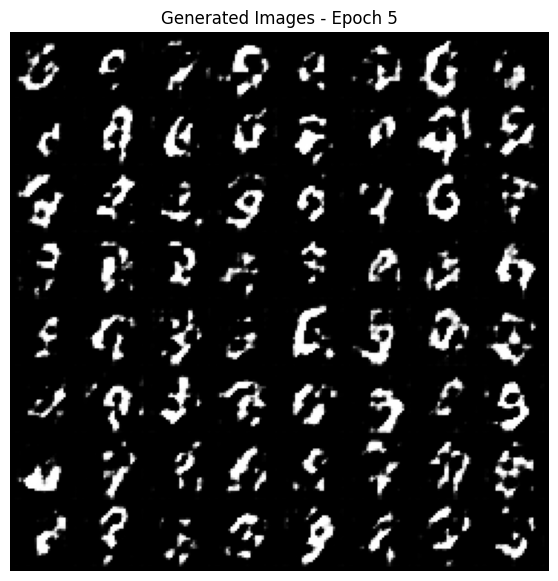

Epoch 6/10 | D Loss: 0.5173 | G Loss: 1.8231
Epoch 7/10 | D Loss: 0.5086 | G Loss: 2.0375
Epoch 8/10 | D Loss: 0.5212 | G Loss: 2.0180
Epoch 9/10 | D Loss: 0.5270 | G Loss: 1.9224
Epoch 10/10 | D Loss: 0.5608 | G Loss: 2.0325


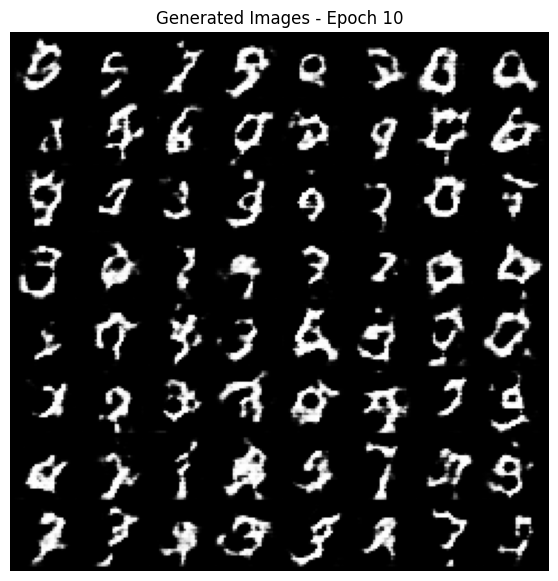

Augmented DCGAN training time: 149.41 seconds
Generator parameters: 810433
Discriminator parameters: 36641


In [16]:
torch.manual_seed(SEED)

augmented_dcgan_generator = DCGANGenerator(latent_dim).to(device)
augmented_dcgan_discriminator = DCGANDiscriminator().to(device)

augmented_dcgan_history, augmented_dcgan_time = train_gan(
    augmented_dcgan_generator,
    augmented_dcgan_discriminator,
    augmented_loader,
    epochs=10,
    latent_dim=latent_dim,
    learning_rate=0.0002,
    sample_filename_prefix="tutorial_16_augmented_dcgan",
    visualize_every=5
)

print("Augmented DCGAN training time:", round(augmented_dcgan_time, 2), "seconds")
print("Generator parameters:", count_trainable_parameters(augmented_dcgan_generator))
print("Discriminator parameters:", count_trainable_parameters(augmented_dcgan_discriminator))


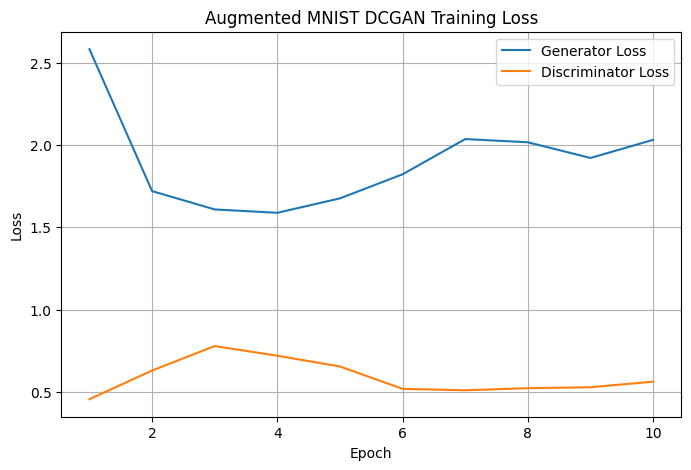

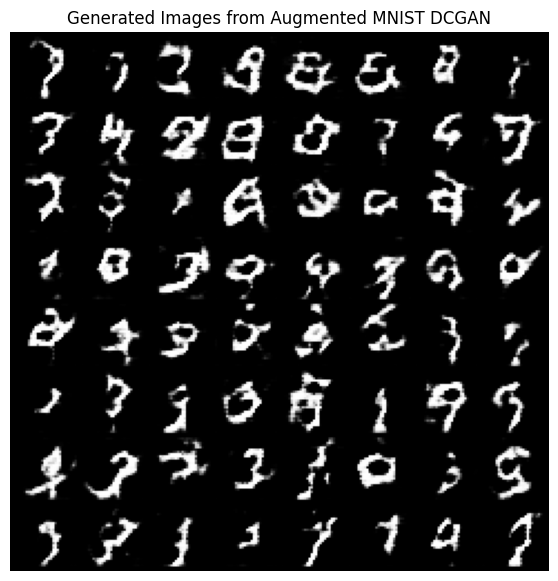

In [17]:
plot_gan_losses(
    augmented_dcgan_history,
    title="Augmented MNIST DCGAN Training Loss",
    filename="images/tutorial_16_augmented_dcgan_loss.png"
)

augmented_dcgan_generator.eval()

with torch.no_grad():
    noise = torch.randn(64, latent_dim).to(device)
    generated_augmented_images = augmented_dcgan_generator(noise)

show_image_grid(
    generated_augmented_images,
    title="Generated Images from Augmented MNIST DCGAN",
    filename="images/tutorial_16_augmented_dcgan_final_generated.png",
    nrow=8
)


## 9. Compare All GAN Models

In [18]:
gan_comparison_df = pd.DataFrame([
    {
        "Model": "FC GAN",
        "Architecture": "Fully connected",
        "Epochs": len(fc_history["generator_loss"]),
        "Final G Loss": fc_history["generator_loss"][-1],
        "Final D Loss": fc_history["discriminator_loss"][-1],
        "Generator Params": count_trainable_parameters(fc_generator),
        "Discriminator Params": count_trainable_parameters(fc_discriminator),
        "Training Time (s)": fc_time
    },
    {
        "Model": "Deep FC GAN",
        "Architecture": "Deeper fully connected",
        "Epochs": len(deep_fc_history["generator_loss"]),
        "Final G Loss": deep_fc_history["generator_loss"][-1],
        "Final D Loss": deep_fc_history["discriminator_loss"][-1],
        "Generator Params": count_trainable_parameters(deep_fc_generator),
        "Discriminator Params": count_trainable_parameters(deep_fc_discriminator),
        "Training Time (s)": deep_fc_time
    },
    {
        "Model": "DCGAN",
        "Architecture": "Convolutional",
        "Epochs": len(dcgan_history["generator_loss"]),
        "Final G Loss": dcgan_history["generator_loss"][-1],
        "Final D Loss": dcgan_history["discriminator_loss"][-1],
        "Generator Params": count_trainable_parameters(dcgan_generator),
        "Discriminator Params": count_trainable_parameters(dcgan_discriminator),
        "Training Time (s)": dcgan_time
    },
    {
        "Model": "Augmented DCGAN",
        "Architecture": "Convolutional on augmented MNIST",
        "Epochs": len(augmented_dcgan_history["generator_loss"]),
        "Final G Loss": augmented_dcgan_history["generator_loss"][-1],
        "Final D Loss": augmented_dcgan_history["discriminator_loss"][-1],
        "Generator Params": count_trainable_parameters(augmented_dcgan_generator),
        "Discriminator Params": count_trainable_parameters(augmented_dcgan_discriminator),
        "Training Time (s)": augmented_dcgan_time
    }
])

gan_comparison_df


,Model,Architecture,Epochs,Final G Loss,Final D Loss,Generator Params,Discriminator Params,Training Time (s)
0,FC GAN,Fully connected,10,3.322759,0.235155,579728,533505,101.373914
1,Deep FC GAN,Deeper fully connected,15,2.656887,0.497882,1609744,1460225,171.188655
2,DCGAN,Convolutional,15,1.764823,0.701286,810433,36641,178.633052
3,Augmented DCGAN,Convolutional on augmented MNIST,10,2.032549,0.560838,810433,36641,149.405619


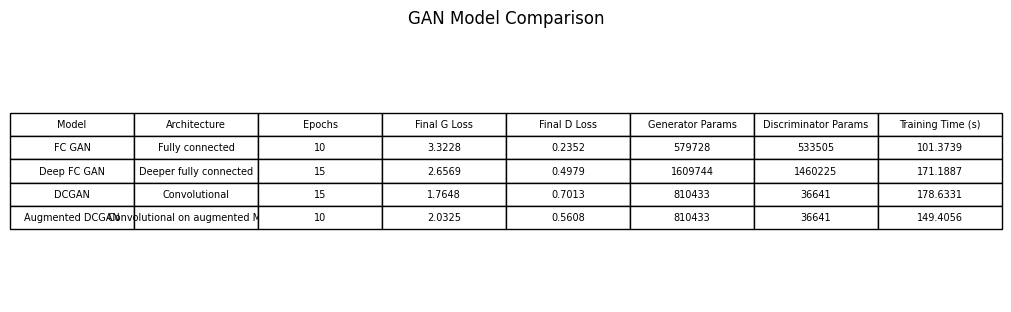

In [19]:
def save_dataframe_as_image(df, filename, title=None, fontsize=8):
    fig_width = max(10, len(df.columns) * 1.6)
    fig_height = max(2.5, len(df) * 0.55 + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.4)

    if title:
        ax.set_title(title, fontsize=12, pad=12)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


gan_comparison_image_df = gan_comparison_df.copy()

for column in ["Final G Loss", "Final D Loss", "Training Time (s)"]:
    gan_comparison_image_df[column] = gan_comparison_image_df[column].round(4)

save_dataframe_as_image(
    gan_comparison_image_df,
    "images/tutorial_16_gan_comparison_table.png",
    title="GAN Model Comparison",
    fontsize=7
)


## 10. Combined Loss Comparison

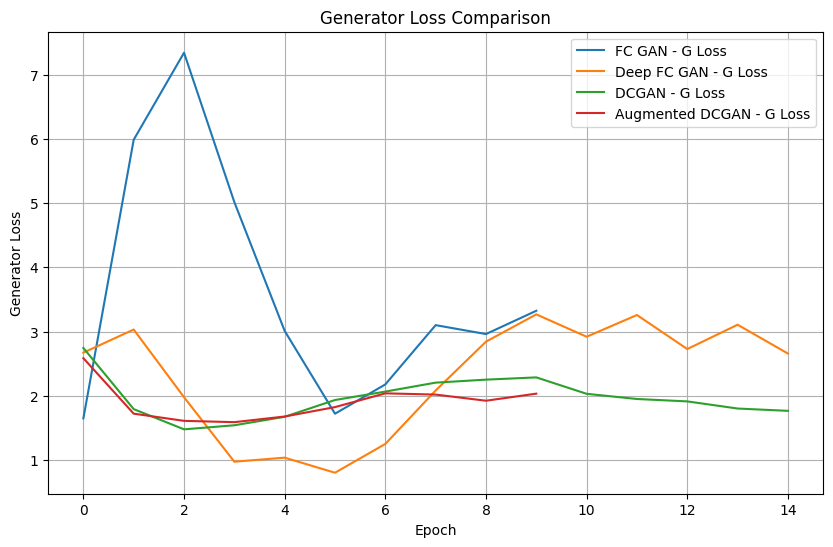

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(fc_history["generator_loss"], label="FC GAN - G Loss")
plt.plot(deep_fc_history["generator_loss"], label="Deep FC GAN - G Loss")
plt.plot(dcgan_history["generator_loss"], label="DCGAN - G Loss")
plt.plot(augmented_dcgan_history["generator_loss"], label="Augmented DCGAN - G Loss")

plt.xlabel("Epoch")
plt.ylabel("Generator Loss")
plt.title("Generator Loss Comparison")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_16_generator_loss_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


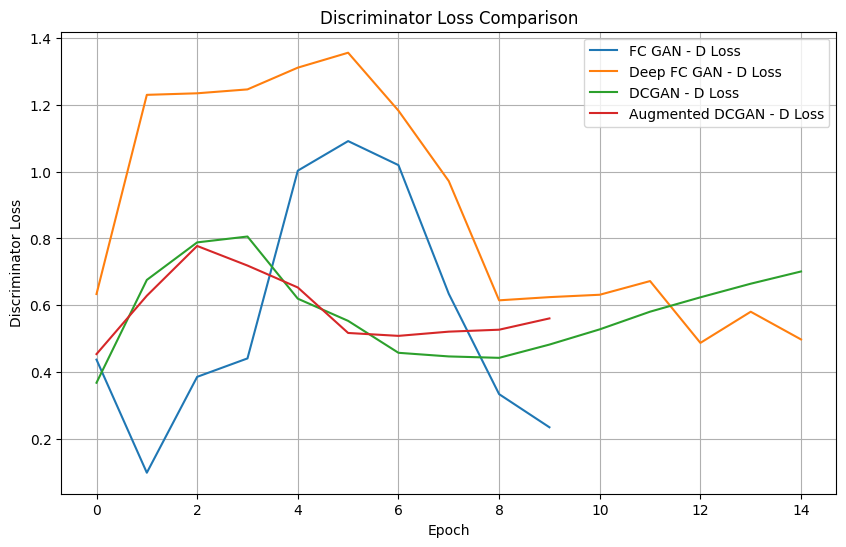

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(fc_history["discriminator_loss"], label="FC GAN - D Loss")
plt.plot(deep_fc_history["discriminator_loss"], label="Deep FC GAN - D Loss")
plt.plot(dcgan_history["discriminator_loss"], label="DCGAN - D Loss")
plt.plot(augmented_dcgan_history["discriminator_loss"], label="Augmented DCGAN - D Loss")

plt.xlabel("Epoch")
plt.ylabel("Discriminator Loss")
plt.title("Discriminator Loss Comparison")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_16_discriminator_loss_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# Final Observations

## Fully Connected GAN

The basic GAN used fully connected layers in both the generator and discriminator.  
It learned to generate digit-like images from random noise.

## Deep Fully Connected GAN

The deeper fully connected GAN used more layers and more neurons.  
This increased model capacity and allowed comparison with the baseline model.

## DCGAN

The DCGAN replaced fully connected layers with convolutional and transposed convolutional layers.  
This is more suitable for image generation because convolutional layers preserve spatial structure.

## Augmented Image GAN

The augmented DCGAN was trained on augmented MNIST images.  
This demonstrated how GANs can also be trained on augmented images from a previous data augmentation study.

## Key Learning

GAN training is adversarial.  
The generator improves by trying to fool the discriminator, while the discriminator improves by trying to distinguish real images from generated images.

A convolutional architecture is generally more suitable for image generation than a purely fully connected architecture.
